In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# read data files

movies  = pd.read_csv("Data/movies.csv")  # Contains movie metadata.
ratings = pd.read_csv("Data/ratings.csv") # Contains user–movie interactions.
tags    = pd.read_csv("Data/tags.csv")    #Contains text descriptions added by users

In [2]:
display(movies.head())
display(ratings.head())
display(tags.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


The **movies** dataset contains three columns: movieId, title, and genres, and does not include any missing values.

In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


The **ratings** dataset is significantly larger and consists of userId, movieId, rating, and timestamp. It also contains no missing values. Due to its size, a subset may be used during development to reduce computational cost.

In [5]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2328315 entries, 0 to 2328314
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 71.1+ MB


The **tags** dataset includes userId, movieId, tag, and timestamp, representing user-generated metadata about movies.

The column **movieId** is common across all three datasets, which allows them to be merged and used together in the recommendation system.

Each dataset serves a different purpose: movies and tags are useful for content-based filtering, while ratings are primarily used for collaborative filtering approaches.

In [6]:
movies['movieId'].nunique() # check the number of movies in the dataset

86537

In [7]:
movies["genres"].unique()

array(['Adventure|Animation|Children|Comedy|Fantasy',
       'Adventure|Children|Fantasy', 'Comedy|Romance', ...,
       'Animation|Children|Comedy|Fantasy|Romance',
       'Comedy|Horror|Mystery|Sci-Fi|Thriller',
       'Action|Adventure|Drama|Horror|Mystery|Thriller'],
      shape=(1796,), dtype=object)

In [8]:
# Split the 'genres' column 
# into a list of individual genres
genres_split = movies['genres'].str.split('|')

genres_exploded = movies.assign(genres=genres_split).explode('genres')

In [9]:
genres_exploded.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children
0,1,Toy Story (1995),Comedy
0,1,Toy Story (1995),Fantasy


In [10]:
genres_exploded['genres'].unique()

array(['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Mystery', 'Sci-Fi', 'IMAX', 'Documentary', 'War', 'Musical',
       'Western', 'Film-Noir', '(no genres listed)'], dtype=object)

We observe that there are 20 unique genres in the dataset. While genres provide a general classification of movies, this limited set of categories may not be sufficient to fully capture the richness and diversity of movie content.

This motivates the use of additional features such as user-generated tags, which provide more detailed and descriptive information about each movie.

In [11]:
genre_counts = genres_exploded['genres'].value_counts()

genre_counts.head(10)

genres
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Name: count, dtype: int64

Movies without genres provide poor information for content-based models

In [12]:
movies = movies[movies['genres'] != '(no genres listed)'] # remove movies without genres

genres_split = movies['genres'].str.split('|')

genres_exploded = movies.assign(genres=genres_split).explode('genres') # Analyze each genre individually

genre_counts = genres_exploded['genres'].value_counts()
genre_counts

genres
Drama          33681
Comedy         22830
Thriller       11675
Romance        10172
Action          9563
Documentary     9283
Horror          8570
Crime           6917
Adventure       5349
Sci-Fi          4850
Animation       4579
Children        4367
Mystery         3972
Fantasy         3821
War             2301
Western         1690
Musical         1059
Film-Noir        354
IMAX             195
Name: count, dtype: int64

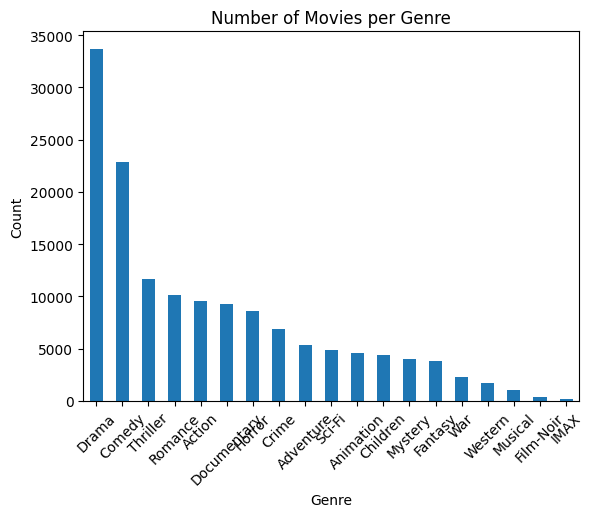

In [13]:
genre_counts.plot(kind='bar')
plt.title("Number of Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


The dataset is highly imbalanced across genres. **Drama** and **Comedy** dominate the dataset, while other genres such as **IMAX** and **Film-Noir** appear significantly less frequently. 

In [14]:
ratings["rating"]. unique() # check which unique values has rating column

array([4. , 4.5, 5. , 3.5, 3. , 2. , 2.5, 1. , 1.5, 0.5])

In [15]:
ratings["rating"].value_counts() # Count how many times each rating value appears

rating
4.0    8835955
3.0    6400664
5.0    4957902
3.5    4465001
4.5    3123055
2.0    2146492
2.5    1760733
1.0    1013645
0.5     566306
1.5     562409
Name: count, dtype: int64

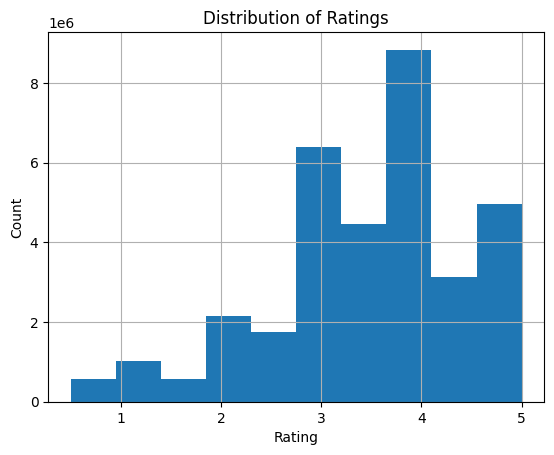

In [16]:
# check ratings distribution

ratings['rating'].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

MovieLens ratings are:

- between 0.5 and 5

- many ratings around 3–4

- fewer very low ratings

This means the ratings are not perfectly evenly distributed, but they already exist on a fixed scale.

Users tend to rate movies they like

In [17]:
ratings["userId"].nunique()
#ratings["movieId"].nunique()


330975

In [18]:
tags['tag'].unique()

array(['good vs evil', 'Harrison Ford', 'sci-fi', ...,
       'jimcarrey-on fire', 'young jim carrey', 'political correct'],
      shape=(153950,), dtype=object)

The dataset contains more than 150,000 unique tags, which provide rich information about movies and make recommendations more effective.

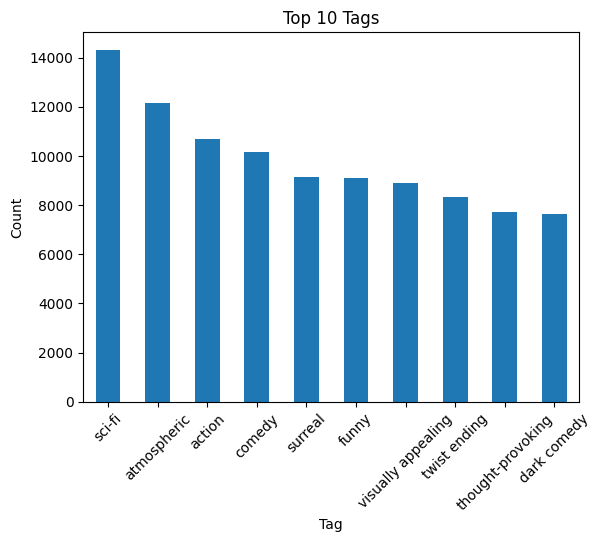

In [19]:
top_tags = tags['tag'].value_counts().head(10)

top_tags.plot(kind='bar')
plt.title("Top 10 Tags")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The most frequent tags include terms such as "sci-fi", "atmospheric", "funny", and "thought-provoking". Unlike genres, tags provide more detailed and descriptive information about movies, including mood, style, and narrative elements. This makes them particularly useful for **content-based recommendation system**.

## **Build Feature Column :**

In [20]:
tag_data = tags.groupby('movieId')['tag'].apply(
    lambda x: ' '.join(set(str(t).lower().strip() for t in x if pd.notna(t)))
) # For each movie → clean tags → remove duplicates → combine into one string

tag_data.head()

movieId
1    dental braces talking in one's sleep https://m...
2    critter recluse adaptation of book exterminato...
3    walter matthau clv old old man howard deutch o...
4    divorce characters chick flick clv girl movie ...
5    fourth wall worst movies ever touching remake ...
Name: tag, dtype: object

In [21]:
movies = movies.merge(tag_data, on='movieId', how='left') # merge with movies
movies.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,dental braces talking in one's sleep https://m...
1,2,Jumanji (1995),Adventure|Children|Fantasy,critter recluse adaptation of book exterminato...
2,3,Grumpier Old Men (1995),Comedy|Romance,walter matthau clv old old man howard deutch o...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,divorce characters chick flick clv girl movie ...
4,5,Father of the Bride Part II (1995),Comedy,fourth wall worst movies ever touching remake ...


In [22]:
movies['content'] = movies['genres'] + " " + movies['tag'] # add a new column 'content' includes both genre and tags

In [23]:
movies[['title', 'content']].head()

,title,content
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy de...
1,Jumanji (1995),Adventure|Children|Fantasy critter recluse ada...
2,Grumpier Old Men (1995),Comedy|Romance walter matthau clv old old man ...
3,Waiting to Exhale (1995),Comedy|Drama|Romance divorce characters chick ...
4,Father of the Bride Part II (1995),Comedy fourth wall worst movies ever touching ...


A combined feature column was created by merging genres and user-generated tags, providing a richer representation of each movie for content-based filtering.

In [24]:
# Replace '|' with spaces so genres can be treated as separate words in TF-IDF
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

# Make sure genres and tags contain strings, not missing values
movies['genres'] = movies['genres'].fillna('')
movies['tag'] = movies['tag'].fillna('')

# Recreate the combined content column
movies['content'] = movies['genres'] + ' ' + movies['tag']

# Make sure content has no missing values
movies['content'] = movies['content'].fillna('')

movies.head()

,movieId,title,genres,tag,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,dental braces talking in one's sleep https://m...,Adventure Animation Children Comedy Fantasy de...
1,2,Jumanji (1995),Adventure Children Fantasy,critter recluse adaptation of book exterminato...,Adventure Children Fantasy critter recluse ada...
2,3,Grumpier Old Men (1995),Comedy Romance,walter matthau clv old old man howard deutch o...,Comedy Romance walter matthau clv old old man ...
3,4,Waiting to Exhale (1995),Comedy Drama Romance,divorce characters chick flick clv girl movie ...,Comedy Drama Romance divorce characters chick ...
4,5,Father of the Bride Part II (1995),Comedy,fourth wall worst movies ever touching remake ...,Comedy fourth wall worst movies ever touching ...


## **TF-IDF vectorization :**

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert each movie's content (genres + tags) into TF-IDF vectors
# removes common, meaningless words 
tfidf = TfidfVectorizer(stop_words='english' ) 
tfidf_matrix = tfidf.fit_transform(movies['content']) 

- fit : Learns vocabulary from  the dataset 
- transform : Converts each movie into a vector

In [26]:
tfidf_matrix.shape

(79477, 51411)

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix[:5000], tfidf_matrix[:5000])
cosine_sim[:10]

array([[1.        , 0.21020291, 0.03233301, ..., 0.05766746, 0.10466845,
        0.        ],
       [0.21020291, 1.        , 0.01983049, ..., 0.06108285, 0.07088378,
        0.        ],
       [0.03233301, 0.01983049, 1.        , ..., 0.04267105, 0.01068644,
        0.        ],
       ...,
       [0.14819397, 0.18292629, 0.00951903, ..., 0.01813924, 0.03577993,
        0.        ],
       [0.13617499, 0.16148084, 0.0137339 , ..., 0.06714763, 0.0155927 ,
        0.        ],
       [0.13063465, 0.15833786, 0.02575946, ..., 0.02321585, 0.03423245,
        0.        ]], shape=(10, 5000))

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Create a mapping from movie title to dataframe index
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [29]:
def recommend_movies(title, tfidf_matrix=tfidf_matrix, movies=movies, indices=indices, top_n=5):
    # Check if the movie exists in the dataset
    if title not in indices:
        return f"Movie '{title}' not found in the dataset."
    
    # Get the index of the input movie
    idx = indices[title]
    
    # Compute cosine similarity between the selected movie and all other movies
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    # Get indices of the most similar movies
    similar_indices = sim_scores.argsort()[::-1]
    
    # Remove the movie itself from the recommendations
    similar_indices = similar_indices[similar_indices != idx]
    
    # Select top N recommendations
    top_indices = similar_indices[:top_n]
    
    # Return recommended movie titles
    return movies[['title']].iloc[top_indices]

In [30]:
recommend_movies("Toy Story 2 (1999)")

,title
0,Toy Story (1995)
14815,Toy Story 3 (2010)
55740,Toy Story 4 (2019)
24058,Toy Story That Time Forgot (2014)
25887,Pound Puppies and the Legend of Big Paw (1988)


In [ ]:
""" 
compare the result of recommnedation with 'content' column

are they have the similar content information!
"""
recs = recommend_movies("Toy Story 2 (1999)")

movies[movies['title'].isin(recs['title'])][['title', 'content']] 

,title,content
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy de...
14815,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IM...
24058,Toy Story That Time Forgot (2014),Animation Children short male villain toy hedg...
25887,Pound Puppies and the Legend of Big Paw (1988),Children based on toy
55740,Toy Story 4 (2019),Adventure Animation Children Comedy shepherdes...


We observe that the model produces reasonable results, as indicated by the information contained in the  'content' column.